In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_parquet('../data/features.parquet')

# Store 1
store1 = df[df['Store'] == 1].sort_values('Date').copy()

# Encode categoricals
le = LabelEncoder()
store1['StoreType_enc'] = le.fit_transform(store1['StoreType'])
store1['Assortment_enc'] = le.fit_transform(store1['Assortment'])

# Feature columns
feature_cols = [
    'DayOfWeek', 'Promo', 'IsStateHoliday', 'IsSchoolHoliday',
    'StoreType_enc', 'Assortment_enc', 'CompetitionDistance',
    'Year', 'Month', 'Week', 'DayOfMonth', 'Quarter',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember',
    'Sales_lag_1', 'Sales_lag_2', 'Sales_lag_3',
    'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_21', 'Sales_lag_28',
    'Sales_rolling_mean_7', 'Sales_rolling_std_7',
    'Sales_rolling_mean_14', 'Sales_rolling_std_14',
    'Sales_rolling_mean_28', 'Sales_rolling_std_28',
    'DayBeforeHoliday', 'DayAfterHoliday',
    'CompetitionOpenMonths', 'Promo2Active'
]

# Train/test split
train = store1[store1['Date'] < '2015-01-01'].dropna(subset=feature_cols).copy()
test = store1[store1['Date'] >= '2015-01-01'].dropna(subset=feature_cols).copy()

print(f"Train: {len(train)} rows")
print(f"Test:  {len(test)} rows")
print(f"Features: {len(feature_cols)}")

Train: 578 rows
Test:  175 rows
Features: 33


In [2]:
# Prepare datasets
X_train = train[feature_cols]
y_train = train['Sales']
X_test = test[feature_cols]
y_test = test['Sales']

# Train LightGBM
params = {
    'objective': 'regression',
    'metric': 'mape',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_test],
    callbacks=callbacks
)

print(f"Best iteration: {model.best_iteration}")
print("LightGBM trained.")

Best iteration: 71
LightGBM trained.


LightGBM Metrics - Store 1 (Test: Jan-Jul 2015)
MAPE: 8.20%
RMSE: 453
MAE:  355


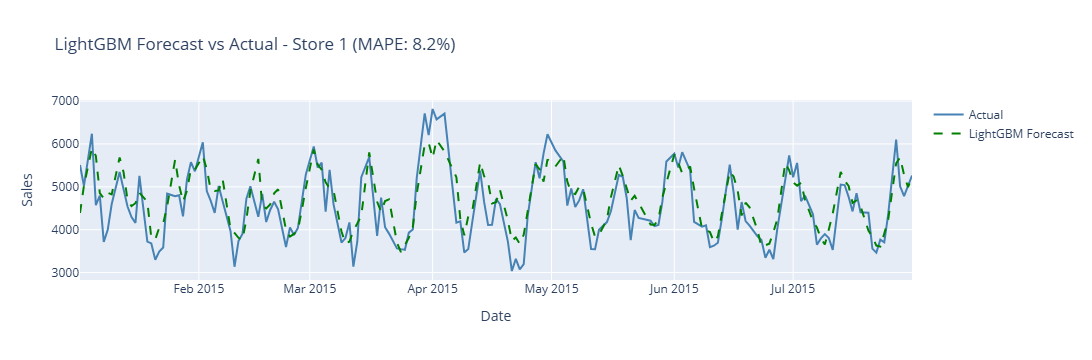

In [3]:
# Predict
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

lgb_mape = mape(y_test.values, y_pred)
lgb_rmse = rmse(y_test.values, y_pred)
lgb_mae = mae(y_test.values, y_pred)

print(f"LightGBM Metrics - Store 1 (Test: Jan-Jul 2015)")
print(f"MAPE: {lgb_mape:.2f}%")
print(f"RMSE: {lgb_rmse:.0f}")
print(f"MAE:  {lgb_mae:.0f}")

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test['Date'],
    y=y_test.values,
    mode='lines',
    name='Actual',
    line=dict(color='steelblue', width=2)
))

fig.add_trace(go.Scatter(
    x=test['Date'],
    y=y_pred,
    mode='lines',
    name='LightGBM Forecast',
    line=dict(color='green', width=2, dash='dash')
))

fig.update_layout(
    title=f'LightGBM Forecast vs Actual - Store 1 (MAPE: {lgb_mape:.1f}%)',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified'
)
fig.show()

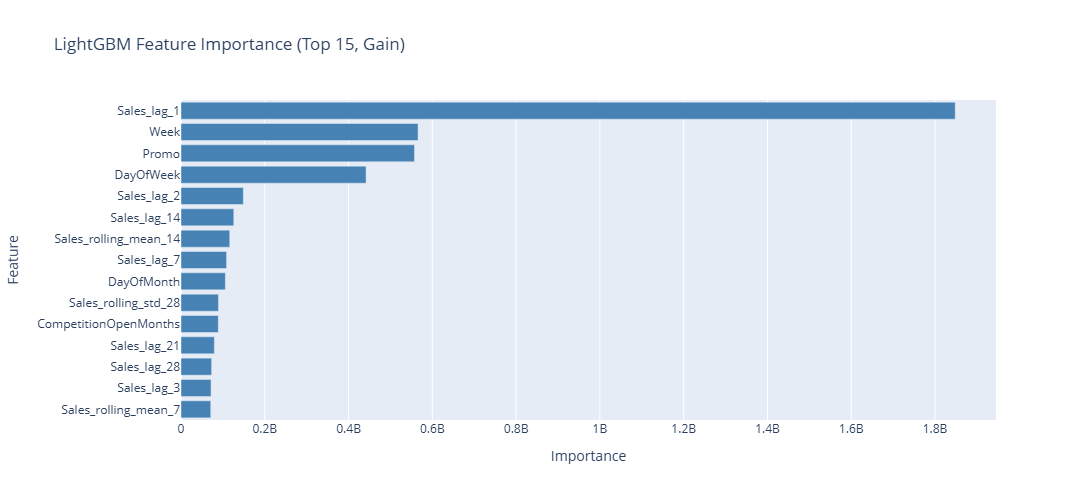


Top 10 features:
                  feature    importance
28   Sales_rolling_std_28  8.947875e+07
10             DayOfMonth  1.059146e+08
19            Sales_lag_7  1.087875e+08
25  Sales_rolling_mean_14  1.163500e+08
20           Sales_lag_14  1.260109e+08
17            Sales_lag_2  1.488075e+08
0               DayOfWeek  4.418011e+08
1                   Promo  5.574135e+08
9                    Week  5.659202e+08
16            Sales_lag_1  1.848275e+09
Saved: ../docs/feature_importance.png


In [7]:
# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(15)

fig = go.Figure(go.Bar(
    x=importance['importance'],
    y=importance['feature'],
    orientation='h',
    marker_color='steelblue'
))

fig.update_layout(
    title='LightGBM Feature Importance (Top 15, Gain)',
    xaxis_title='Importance',
    yaxis_title='Feature',
    height=500
)
fig.show()

print("\nTop 10 features:")
print(importance.tail(10)[['feature', 'importance']].to_string())

import os
os.makedirs("../docs", exist_ok=True)
fig.write_image("../docs/feature_importance.png", width=1200, height=600, scale=2)
print("Saved: ../docs/feature_importance.png")

In [5]:
# Walk-forward CV
cv_results = []
cutoffs = pd.date_range(start='2014-06-01', end='2014-11-01', freq='MS')

print(f"Running {len(cutoffs)} CV folds...")

for cutoff in cutoffs:
    train_fold = store1[store1['Date'] < cutoff].dropna(subset=feature_cols).copy()
    test_fold = store1[
        (store1['Date'] >= cutoff) &
        (store1['Date'] < cutoff + pd.DateOffset(months=1))
    ].dropna(subset=feature_cols).copy()

    if len(test_fold) == 0:
        continue

    X_tr = train_fold[feature_cols]
    y_tr = train_fold['Sales']
    X_te = test_fold[feature_cols]
    y_te = test_fold['Sales']

    lgb_tr = lgb.Dataset(X_tr, label=y_tr)

    m = lgb.train(
        params,
        lgb_tr,
        num_boost_round=model.best_iteration,
        callbacks=[lgb.log_evaluation(period=-1)]
    )

    preds = m.predict(X_te)
    fold_mape = mape(y_te.values, preds)

    cv_results.append({
        'cutoff': cutoff.strftime('%Y-%m'),
        'mape': round(fold_mape, 2),
        'n_train': len(train_fold),
        'n_test': len(test_fold)
    })
    print(f"  Fold {cutoff.strftime('%Y-%m')}: MAPE={fold_mape:.1f}%")

cv_df = pd.DataFrame(cv_results)
print(f"\nMean CV MAPE: {cv_df['mape'].mean():.2f}%")
print(f"Std CV MAPE:  {cv_df['mape'].std():.2f}%")

Running 6 CV folds...
  Fold 2014-06: MAPE=10.0%
  Fold 2014-07: MAPE=6.5%
  Fold 2014-08: MAPE=10.3%
  Fold 2014-09: MAPE=10.6%
  Fold 2014-10: MAPE=6.4%
  Fold 2014-11: MAPE=10.8%

Mean CV MAPE: 9.09%
Std CV MAPE:  2.08%


In [6]:
import json

lgb_results = {
    'model': 'LightGBM',
    'test_mape': round(lgb_mape, 2),
    'test_rmse': round(lgb_rmse, 0),
    'test_mae': round(lgb_mae, 0),
    'cv_mape_mean': round(cv_df['mape'].mean(), 2),
    'cv_mape_std': round(cv_df['mape'].std(), 2),
    'best_iteration': model.best_iteration,
    'top_feature': 'Sales_lag_1'
}

with open('../data/lgb_results.json', 'w') as f:
    json.dump(lgb_results, f)

print("Saved to data/lgb_results.json")
print(f"\nLightGBM Summary - Store 1:")
for k, v in lgb_results.items():
    print(f"  {k}: {v}")

Saved to data/lgb_results.json

LightGBM Summary - Store 1:
  model: LightGBM
  test_mape: 8.2
  test_rmse: 453.0
  test_mae: 355.0
  cv_mape_mean: 9.09
  cv_mape_std: 2.08
  best_iteration: 71
  top_feature: Sales_lag_1
